# AoS vs SoA for a Finite-Volume Flux Kernel
### When the arithmetic is identical, does layout control throughput?

**Learning goal:** Implement the same 1D Euler/Rusanov residual kernel using array-of-structures (AoS) and structure-of-arrays (SoA) storage, verify numerical equivalence, and explain measured throughput using stride, working-set size, and a simple bandwidth model.

**Time:** 60-90 minutes. Python, NumPy, Numba, Matplotlib. Use one fixed physical state per problem size; this is a performance experiment, not a grid-convergence study.

**Primary question:** Which layout better matches the loop and field-access pattern on your CPU, and does the answer change between fused and split kernels?

**Success targets:** Both layouts agree to tight floating-point tolerance; all generated states remain physically admissible; timings exclude compilation and allocation; results report median time, cell-updates/s, estimated useful bandwidth, and run-to-run spread.

The code cells contain a fully commented implementation. Predict the winner before measuring, then run the cells in order. A performance result without a verified equivalent computation is not valid.

## 1. Kernel and storage layouts

For the 1D Euler conserved state
$$U=(\rho,\rho u,E)^T,\qquad p=(\gamma-1)\left(E-\tfrac12\rho u^2\right),$$
the physical flux is
$$F(U)=\left(\rho u,\rho u^2+p,u(E+p)\right)^T.$$
At each periodic face, evaluate the local Lax-Friedrichs/Rusanov flux
$$F_{i+1/2}=\tfrac12\left[F(U_i)+F(U_{i+1})\right]-\tfrac12s_{i+1/2}(U_{i+1}-U_i),$$
where $s_{i+1/2}=\max(|u_i|+c_i,|u_{i+1}|+c_{i+1})$ and $c=\sqrt{\gamma p/\rho}$.
Return the unscaled residual $R_i=F_{i+1/2}-F_{i-1/2}$. Do not advance a solution in time.

Implement the identical operation in two layouts:

- **AoS:** one C-contiguous array `U.shape == (N, 3)`; the three fields for one cell are adjacent.
- **SoA:** three C-contiguous arrays `rho`, `mom`, and `energy`; one field is adjacent across cells.

Use explicit Numba loops with periodic index wrap. Do not use `np.roll`, temporary face arrays, parallel execution, or `fastmath` in the required experiment; those alter the memory traffic or numerical contract. Preallocate outputs.

In [16]:
import os
import platform
import sys
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter_ns

try:
    from numba import njit, __version__ as numba_version, get_num_threads
except ImportError as exc:
    raise RuntimeError("Install numba for this exercise: python -m pip install numba") from exc

# Ratio of specific heats for the ideal-gas Euler equations.
GAMMA = 1.4
# The largest case has over 100 MiB of combined input and output arrays.
SIZES = (2**12, 2**15, 2**18, 2**22)
REPEATS = 9
SEED = 8

# Capture enough context to judge how portable the timing results may be.
# Some virtual machines do not expose a CPU model, so keep the OS string too.
CPU_MODEL = platform.processor() or platform.uname().processor or "not reported by OS"
SOFTWARE_CONTEXT = {
    "cpu_model": CPU_MODEL,
    "platform": platform.platform(),
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "numba": numba_version,
    "logical_cpu_count": os.cpu_count(),
    "numba_thread_pool_size": get_num_threads(),
    "kernel_execution": "serial; no parallel=True",
}

# Predict before measuring: AoS keeps all three values of a cell together,
# while SoA gives each conserved field a contiguous stream. Either may win
# depending on cache behavior and compiler vectorization, so do not assume.
PREDICTION = (
    "No universal winner is assumed. AoS provides nearby fields per cell; "
    "SoA provides contiguous field streams. The measured result decides."
)

# Use consistent plot defaults so the three comparisons are easy to read.
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

print("Benchmark context:")
for name, value in SOFTWARE_CONTEXT.items():
    print(f"  {name}: {value}")
print("Prediction:", PREDICTION)
print("The kernels are serial regardless of the available Numba thread pool.")


Benchmark context:
  cpu_model: AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD
  platform: Windows-11-10.0.26200-SP0
  python: 3.13.14
  numpy: 2.5.3
  numba: 0.68.0
  logical_cpu_count: 8
  numba_thread_pool_size: 8
  kernel_execution: serial; no parallel=True
Prediction: No universal winner is assumed. AoS provides nearby fields per cell; SoA provides contiguous field streams. The measured result decides.
The kernels are serial regardless of the available Numba thread pool.


## 2. Reproducible admissible state

Generate one smooth-but-nonuniform state for each N using cell centers $x_i=(i+1/2)/N$:
$$\rho=1+0.15\sin(2\pi x)+0.03\eta_\rho,$$
$$u=0.35+0.10\cos(6\pi x)+0.02\eta_u,$$
$$p=1+0.10\sin(4\pi x+0.3)+0.03\eta_p,$$
where each seeded random component is uniform on $[-1,1]$. Construct $\rho u$ and $E=p/(\gamma-1)+\rho u^2/2$.

Create AoS and SoA inputs from the same underlying values. Assert positive density and pressure. Print array shapes, strides, contiguity flags, and total input/output bytes. Explain which index is unit-stride in each representation.

Allocate every array before timing. The output layout must match the input layout. Use float64 for the main experiment.

In [17]:
def make_state(n, seed=SEED):
    """Generate the specified deterministic state in both contiguous layouts."""
    # Cell-center coordinates are common to both layouts, so each cell has
    # identical physical values regardless of how those values are stored.
    x = (np.arange(n, dtype=np.float64) + 0.5) / n
    rng = np.random.default_rng(seed)

    # Draw independent bounded perturbations, as prescribed by the exercise.
    noise_rho = rng.uniform(-1.0, 1.0, size=n)
    noise_u = rng.uniform(-1.0, 1.0, size=n)
    noise_p = rng.uniform(-1.0, 1.0, size=n)
    rho = 1.0 + 0.15 * np.sin(2.0 * np.pi * x) + 0.03 * noise_rho
    velocity = 0.35 + 0.10 * np.cos(6.0 * np.pi * x) + 0.02 * noise_u
    pressure = 1.0 + 0.10 * np.sin(4.0 * np.pi * x + 0.3) + 0.03 * noise_p

    # Convert primitive variables to conserved variables for the Euler system.
    momentum = rho * velocity
    energy = pressure / (GAMMA - 1.0) + 0.5 * rho * velocity**2

    # AoS stores all variables for a cell in one row; SoA stores each field
    # in its own contiguous vector. Explicit dtype/order avoids hidden copies.
    aos = np.empty((n, 3), dtype=np.float64, order="C")
    aos[:, 0] = rho
    aos[:, 1] = momentum
    aos[:, 2] = energy
    soa = (
        np.ascontiguousarray(rho, dtype=np.float64),
        np.ascontiguousarray(momentum, dtype=np.float64),
        np.ascontiguousarray(energy, dtype=np.float64),
    )
    return aos, soa

@njit(cache=True, inline="always")
def euler_flux_and_speed(rho, momentum, energy, gamma):
    """Return physical flux components and |u|+c for one admissible state."""
    # Recover primitive variables from the conserved state U=(rho,rho*u,E).
    velocity = momentum / rho
    pressure = (gamma - 1.0) * (energy - 0.5 * momentum * velocity)
    sound_speed = np.sqrt(gamma * pressure / rho)

    # The Euler flux is (momentum, momentum*u+p, u*(E+p)).
    flux_rho = momentum
    flux_momentum = momentum * velocity + pressure
    flux_energy = velocity * (energy + pressure)
    wave_speed = abs(velocity) + sound_speed
    return flux_rho, flux_momentum, flux_energy, wave_speed

@njit(cache=True)
def rusanov_face(left_rho, left_mom, left_energy,
                 right_rho, right_mom, right_energy, gamma):
    """Compute one local Lax-Friedrichs/Rusanov numerical face flux."""
    # Evaluate the physical flux and signal speed on both sides of the face.
    fl0, fl1, fl2, sl = euler_flux_and_speed(left_rho, left_mom, left_energy, gamma)
    fr0, fr1, fr2, sr = euler_flux_and_speed(right_rho, right_mom, right_energy, gamma)
    speed = max(sl, sr)

    # Average physical fluxes, then subtract numerical diffusion proportional
    # to the jump in each conserved quantity.
    half_speed = 0.5 * speed
    face_rho = 0.5 * (fl0 + fr0) - half_speed * (right_rho - left_rho)
    face_mom = 0.5 * (fl1 + fr1) - half_speed * (right_mom - left_mom)
    face_energy = 0.5 * (fl2 + fr2) - half_speed * (right_energy - left_energy)
    return face_rho, face_mom, face_energy

@njit(cache=True)
def residual_aos(U, R, gamma):
    """Write periodic Rusanov flux differences into preallocated AoS output."""
    n = U.shape[0]
    for i in range(n):
        # Indices wrap around because the domain is periodic. The right face
        # is between i and i+1; the left face is between i-1 and i.
        ip = i + 1
        if ip == n:
            ip = 0
        im = i - 1
        if im < 0:
            im = n - 1

        # F_{i+1/2} and F_{i-1/2} are evaluated using the same helper and
        # operation order as the SoA kernel to make this a fair comparison.
        right0, right1, right2 = rusanov_face(
            U[i, 0], U[i, 1], U[i, 2], U[ip, 0], U[ip, 1], U[ip, 2], gamma
        )
        left0, left1, left2 = rusanov_face(
            U[im, 0], U[im, 1], U[im, 2], U[i, 0], U[i, 1], U[i, 2], gamma
        )

        # Store flux divergence (right minus left), without a time step or
        # cell-width scale: this function computes residual only.
        R[i, 0] = right0 - left0
        R[i, 1] = right1 - left1
        R[i, 2] = right2 - left2

@njit(cache=True)
def residual_soa(rho, mom, energy, r_rho, r_mom, r_energy, gamma):
    """Write the identical periodic residual into three preallocated SoA arrays."""
    n = rho.shape[0]
    for i in range(n):
        # Use precisely the same periodic neighbors as in the AoS version.
        ip = i + 1
        if ip == n:
            ip = 0
        im = i - 1
        if im < 0:
            im = n - 1

        # Passing six scalar conserved values leaves storage layout as the
        # only change; the shared face routine keeps the arithmetic identical.
        right0, right1, right2 = rusanov_face(
            rho[i], mom[i], energy[i], rho[ip], mom[ip], energy[ip], gamma
        )
        left0, left1, left2 = rusanov_face(
            rho[im], mom[im], energy[im], rho[i], mom[i], energy[i], gamma
        )

        # Each output vector is contiguous; overwrite rather than accumulate.
        r_rho[i] = right0 - left0
        r_mom[i] = right1 - left1
        r_energy[i] = right2 - left2

# Optional stretch: split primitive/physical-flux work from the face loop.
# Each row/vector stores three physical-flux components plus one wave speed.
@njit(cache=True)
def prepare_aos(U, prepared, gamma):
    """First split pass: compute physical fluxes and signal speeds per cell."""
    for i in range(U.shape[0]):
        # This evaluates primitive variables only once per cell and stores
        # the face-independent quantities needed by the second pass.
        f0, f1, f2, speed = euler_flux_and_speed(
            U[i, 0], U[i, 1], U[i, 2], gamma
        )
        prepared[i, 0] = f0
        prepared[i, 1] = f1
        prepared[i, 2] = f2
        prepared[i, 3] = speed

@njit(cache=True)
def prepare_soa(rho, mom, energy, f_rho, f_mom, f_energy, speed, gamma):
    """First split pass for SoA: write flux and signal-speed field vectors."""
    for i in range(rho.shape[0]):
        # The arithmetic is shared with the AoS preparation pass; only the
        # addresses used to read and write values differ by storage layout.
        f0, f1, f2, cell_speed = euler_flux_and_speed(
            rho[i], mom[i], energy[i], gamma
        )
        f_rho[i] = f0
        f_mom[i] = f1
        f_energy[i] = f2
        speed[i] = cell_speed

@njit(cache=True, inline="always")
def cached_rusanov_face(left_rho, left_mom, left_energy,
                        right_rho, right_mom, right_energy,
                        lf0, lf1, lf2, ls, rf0, rf1, rf2, rs):
    """Evaluate a Rusanov face from precomputed physical fluxes and speeds."""
    # The second pass needs the conserved jump for numerical diffusion and
    # reuses the flux/speed arrays generated by the first pass.
    speed = max(ls, rs)
    half_speed = 0.5 * speed
    face0 = 0.5 * (lf0 + rf0) - half_speed * (right_rho - left_rho)
    face1 = 0.5 * (lf1 + rf1) - half_speed * (right_mom - left_mom)
    face2 = 0.5 * (lf2 + rf2) - half_speed * (right_energy - left_energy)
    return face0, face1, face2

@njit(cache=True)
def finish_aos(U, prepared, R):
    """Second split pass: compute cached periodic face flux differences for AoS."""
    n = U.shape[0]
    for i in range(n):
        # Preserve the same periodic neighbors as the fused implementation.
        ip = i + 1
        if ip == n:
            ip = 0
        im = i - 1
        if im < 0:
            im = n - 1
        right0, right1, right2 = cached_rusanov_face(
            U[i, 0], U[i, 1], U[i, 2], U[ip, 0], U[ip, 1], U[ip, 2],
            prepared[i, 0], prepared[i, 1], prepared[i, 2], prepared[i, 3],
            prepared[ip, 0], prepared[ip, 1], prepared[ip, 2], prepared[ip, 3],
        )
        left0, left1, left2 = cached_rusanov_face(
            U[im, 0], U[im, 1], U[im, 2], U[i, 0], U[i, 1], U[i, 2],
            prepared[im, 0], prepared[im, 1], prepared[im, 2], prepared[im, 3],
            prepared[i, 0], prepared[i, 1], prepared[i, 2], prepared[i, 3],
        )
        R[i, 0] = right0 - left0
        R[i, 1] = right1 - left1
        R[i, 2] = right2 - left2

@njit(cache=True)
def finish_soa(rho, mom, energy, f_rho, f_mom, f_energy, speed,
               r_rho, r_mom, r_energy):
    """Second split pass for SoA: write cached periodic flux differences."""
    n = rho.shape[0]
    for i in range(n):
        # Wrap once per cell and reuse those indices for each conserved field.
        ip = i + 1
        if ip == n:
            ip = 0
        im = i - 1
        if im < 0:
            im = n - 1
        right0, right1, right2 = cached_rusanov_face(
            rho[i], mom[i], energy[i], rho[ip], mom[ip], energy[ip],
            f_rho[i], f_mom[i], f_energy[i], speed[i],
            f_rho[ip], f_mom[ip], f_energy[ip], speed[ip],
        )
        left0, left1, left2 = cached_rusanov_face(
            rho[im], mom[im], energy[im], rho[i], mom[i], energy[i],
            f_rho[im], f_mom[im], f_energy[im], speed[im],
            f_rho[i], f_mom[i], f_energy[i], speed[i],
        )
        r_rho[i] = right0 - left0
        r_mom[i] = right1 - left1
        r_energy[i] = right2 - left2

def run_split_aos(U, prepared, R):
    """Run both preallocated AoS passes; keeping this wrapper makes timing fair."""
    prepare_aos(U, prepared, GAMMA)
    finish_aos(U, prepared, R)

def run_split_soa(rho, mom, energy, prepared, outputs):
    """Run both preallocated SoA passes with no allocations in the timed call."""
    prepare_soa(rho, mom, energy, *prepared, GAMMA)
    finish_soa(rho, mom, energy, *prepared,
               outputs[0], outputs[1], outputs[2])


## 3. Correctness before performance

Compile both kernels with a small state, then compare the three residual components. Because the mathematical operations and intended order are the same, require
$$\frac{\|R_{AoS}-R_{SoA}\|_2}{\max(\|R_{AoS}\|_2,10^{-300})}\le 5\times10^{-13}$$
and maximum componentwise absolute difference $\le 5\times10^{-13}$ for the supplied state range.

Also check: finite outputs; discrete conservation `abs(sum(R[:,k])) <= 2e-12*N*max(abs(R[:,k]))` for every conserved component; repeated calls overwrite rather than accumulate; and the input arrays are unchanged.

These are equivalence and conservation checks on a fixed workload. They are not spatial-error or observed-order calculations.

In [18]:
# Start small so Numba compiles the two layouts before any long run. The
# dimensions and dtypes are the same as the large experiment, just fewer cells.
CHECK_N = 64
U_check, (rho_check, mom_check, energy_check) = make_state(CHECK_N)
R_aos_check = np.empty_like(U_check)
r_rho_check = np.empty_like(rho_check)
r_mom_check = np.empty_like(mom_check)
r_energy_check = np.empty_like(energy_check)

# Save exact input copies; kernels are only allowed to write the supplied outputs.
U_check_before = U_check.copy()
soa_check_before = tuple(a.copy() for a in (rho_check, mom_check, energy_check))
residual_aos(U_check, R_aos_check, GAMMA)
residual_soa(rho_check, mom_check, energy_check,
             r_rho_check, r_mom_check, r_energy_check, GAMMA)
R_soa_check = np.column_stack((r_rho_check, r_mom_check, r_energy_check))

# Compare both a scaled norm and the worst component; these catch different
# failure modes and implement the tight tolerance required by the exercise.
difference = R_aos_check - R_soa_check
relative_difference = np.linalg.norm(difference) / max(np.linalg.norm(R_aos_check), 1e-300)
maximum_difference = np.max(np.abs(difference))
assert relative_difference <= 5e-13, relative_difference
assert maximum_difference <= 5e-13, maximum_difference

# Periodic flux differences telescope: sum_i(F_{i+1/2}-F_{i-1/2}) is zero.
assert np.isfinite(R_aos_check).all()
for component in range(3):
    component_scale = max(np.max(np.abs(R_aos_check[:, component])), 1e-300)
    assert abs(np.sum(R_aos_check[:, component])) <= 2e-12 * CHECK_N * component_scale

# A second invocation must overwrite the complete output with identical values,
# not add another residual onto old values. Sentinel fill makes this explicit.
R_aos_expected = R_aos_check.copy()
R_aos_check.fill(123.0)
for output in (r_rho_check, r_mom_check, r_energy_check):
    output.fill(-456.0)
residual_aos(U_check, R_aos_check, GAMMA)
residual_soa(rho_check, mom_check, energy_check,
             r_rho_check, r_mom_check, r_energy_check, GAMMA)
assert np.array_equal(R_aos_check, R_aos_expected)
assert np.array_equal(np.column_stack((r_rho_check, r_mom_check, r_energy_check)), R_soa_check)
assert np.array_equal(U_check, U_check_before)
for current, before in zip((rho_check, mom_check, energy_check), soa_check_before):
    assert np.array_equal(current, before)

# Print actual layout facts. The last axis of AoS is unit-stride; each SoA
# field vector is unit-stride across cells. Include input plus output bytes.
aos_bytes = U_check.nbytes + R_aos_check.nbytes
soa_bytes = sum(a.nbytes for a in (rho_check, mom_check, energy_check,
                                   r_rho_check, r_mom_check, r_energy_check))
print("Correctness check state layout:")
print("  AoS shape/strides/contiguous:", U_check.shape, U_check.strides, U_check.flags.c_contiguous)
print("  SoA shapes/strides/contiguous:",
      [a.shape for a in (rho_check, mom_check, energy_check)],
      [a.strides for a in (rho_check, mom_check, energy_check)],
      [a.flags.c_contiguous for a in (rho_check, mom_check, energy_check)])
print("  Output shapes/strides/contiguous:",
      [R_aos_check.shape, r_rho_check.shape, r_mom_check.shape, r_energy_check.shape],
      [R_aos_check.strides, r_rho_check.strides, r_mom_check.strides, r_energy_check.strides],
      [R_aos_check.flags.c_contiguous, r_rho_check.flags.c_contiguous,
       r_mom_check.flags.c_contiguous, r_energy_check.flags.c_contiguous])
print(f"  input+output bytes per layout: AoS={aos_bytes:,}, SoA={soa_bytes:,}")
print(f"  relative residual difference={relative_difference:.3e}; max abs difference={maximum_difference:.3e}")
print("  Numba signatures compiled:", len(residual_aos.signatures), len(residual_soa.signatures))


Correctness check state layout:
  AoS shape/strides/contiguous: (64, 3) (24, 8) True
  SoA shapes/strides/contiguous: [(64,), (64,), (64,)] [(8,), (8,), (8,)] [True, True, True]
  Output shapes/strides/contiguous: [(64, 3), (64,), (64,), (64,)] [(24, 8), (8,), (8,), (8,)] [True, True, True, True]
  input+output bytes per layout: AoS=3,072, SoA=3,072
  relative residual difference=0.000e+00; max abs difference=0.000e+00
  Numba signatures compiled: 1 1


## 4. Timing protocol and traffic model

For each N and layout:

1. Build and allocate outside the timed region.
2. Warm the compiled kernel at least twice at that N.
3. Time enough consecutive calls per sample that a sample lasts roughly 0.1-0.5 s; determine this batch count with an untimed pilot.
4. Collect nine samples with `perf_counter_ns`; report median and interquartile range per call.
5. Alternate AoS-first and SoA-first across problem sizes to reduce ordering bias. Do not time notebook display, allocation, compilation, conversion, or validation.

Report throughput in million cell updates/s. Construct a transparent **lower-bound useful-traffic model**: each residual evaluation must at least read the three conserved fields and write the three residual fields once, or 48 bytes/cell in float64. Thus
$$B_{useful}=48N/t.$$
This is not measured DRAM traffic: neighbor reuse, write allocation, cache hierarchy, scalar reloads, and compiler transformations change physical traffic. Label it `estimated useful bandwidth`, never `hardware bandwidth`.

Estimate arithmetic intensity by explicitly counting the main floating-point operations in your implementation and dividing by the 48-byte lower bound. State how square root, comparison, and division complicate a single-FLOP model.

In [19]:
def choose_batch_count(call, target_s=0.2):
    """Choose a positive repetition count from one untimed pilot call."""
    # The pilot includes only the already-compiled kernel call; its elapsed
    # time is not retained as a performance sample.
    start = perf_counter_ns()
    call()
    pilot_s = max((perf_counter_ns() - start) * 1e-9, 1e-9)
    # Target a moderate sample duration and cap pathological counts if a
    # tiny call is below timer resolution. max(1, ...) prevents zero repeats.
    return max(1, min(100_000, int(np.ceil(target_s / pilot_s))))

def benchmark(call, batch_count, repeats=REPEATS):
    """Return raw seconds-per-call samples for a preallocated compiled kernel."""
    if batch_count < 1 or repeats < 1:
        raise ValueError("batch_count and repeats must both be positive.")
    samples = np.empty(repeats, dtype=np.float64)
    for sample_index in range(repeats):
        start = perf_counter_ns()
        # Keep allocation, validation, conversion, and display out of this loop.
        for _ in range(batch_count):
            call()
        elapsed_s = (perf_counter_ns() - start) * 1e-9
        samples[sample_index] = elapsed_s / batch_count
    return samples

# For each size, keep only this case's arrays alive. The arrays for the next
# case are created after these references are released to limit peak memory.
records = []
for size_index, n in enumerate(SIZES):
    U, (rho, mom, energy) = make_state(n)
    R = np.empty_like(U)
    r_rho = np.empty_like(rho)
    r_mom = np.empty_like(mom)
    r_energy = np.empty_like(energy)

    # Alternating first layout reduces systematic benefit from always running
    # the same representation first (warm caches, drift, or frequency changes).
    aos_first = (size_index % 2 == 0)
    layout_order = ("AoS", "SoA") if aos_first else ("SoA", "AoS")
    calls = {
        "AoS": lambda: residual_aos(U, R, GAMMA),
        "SoA": lambda: residual_soa(rho, mom, energy,
                                    r_rho, r_mom, r_energy, GAMMA),
    }

    for layout in layout_order:
        call = calls[layout]
        # Warm this exact size at least twice after compilation; the pilot
        # inside choose_batch_count adds another call but is not timed as data.
        call()
        call()
        batch_count = choose_batch_count(call, target_s=0.2)
        samples = benchmark(call, batch_count, repeats=REPEATS)
        median_s = float(np.median(samples))
        q1_s, q3_s = np.percentile(samples, [25, 75])

        # Both layouts read 3 and write 3 float64 values per cell in the
        # documented useful-traffic lower bound (48 bytes per cell).
        useful_bytes = 48 * n
        working_set_bytes = 6 * 8 * n
        records.append({
            "N": n,
            "layout": layout,
            "samples_s": samples,
            "median_s": median_s,
            "q1_s": float(q1_s),
            "q3_s": float(q3_s),
            "iqr_s": float(q3_s - q1_s),
            "batch_count": batch_count,
            "repeats": REPEATS,
            "mlups": n / median_s / 1e6,
            "useful_bytes": useful_bytes,
            "estimated_useful_gbps": useful_bytes / median_s / 1e9,
            "working_set_bytes": working_set_bytes,
            "input_strides": U.strides if layout == "AoS" else (rho.strides, mom.strides, energy.strides),
            "output_strides": R.strides if layout == "AoS" else (r_rho.strides, r_mom.strides, r_energy.strides),
            "signatures_present": bool(residual_aos.signatures and residual_soa.signatures),
        })
        print(f"N={n:>8,} {layout:>3} batch={batch_count:>5,} "
              f"median={median_s:.4e} s MLUPS={n / median_s / 1e6:.2f}")

    # Drop the large inputs and outputs before allocating the next grid.
    del U, rho, mom, energy, R, r_rho, r_mom, r_energy, calls
    del call

print(f"Recorded {len(records)} fused configurations; each has {REPEATS} raw samples.")

# Stretch comparison: now measure the two-pass form at only the two largest
# sizes. This isolates the cost of materializing flux/speed temporaries from
# the required fused kernel, while reusing the same state and timing protocol.
split_records = []
for n in SIZES[-2:]:
    U, (rho, mom, energy) = make_state(n)
    R_fused = np.empty_like(U)
    r_rho_fused = np.empty_like(rho)
    r_mom_fused = np.empty_like(mom)
    r_energy_fused = np.empty_like(energy)

    # First measure AoS split: one N-by-4 scratch array holds three fluxes
    # and one wave speed; outputs and all scratch storage are preallocated.
    prepared_aos = np.empty((n, 4), dtype=np.float64, order="C")
    R_split_aos = np.empty_like(U)
    residual_aos(U, R_fused, GAMMA)
    run_split_aos(U, prepared_aos, R_split_aos)
    aos_error = np.max(np.abs(R_fused - R_split_aos))
    assert np.allclose(R_fused, R_split_aos, rtol=5e-13, atol=5e-13), aos_error
    aos_call = lambda: run_split_aos(U, prepared_aos, R_split_aos)
    aos_call()
    aos_call()
    aos_batch = choose_batch_count(aos_call, target_s=0.2)
    aos_samples = benchmark(aos_call, aos_batch, repeats=REPEATS)
    aos_median = float(np.median(aos_samples))
    aos_q1, aos_q3 = np.percentile(aos_samples, [25, 75])
    split_records.append({
        "N": n, "layout": "AoS", "samples_s": aos_samples,
        "median_s": aos_median, "q1_s": float(aos_q1), "q3_s": float(aos_q3),
        "iqr_s": float(aos_q3 - aos_q1), "batch_count": aos_batch,
        "repeats": REPEATS, "max_fused_difference": float(aos_error),
        "working_set_bytes": 80 * n, "traffic_bytes": 136 * n,
        "estimated_useful_gbps": 136 * n / aos_median / 1e9,
        "signatures_present": bool(prepare_aos.signatures and finish_aos.signatures),
    })
    del prepared_aos, R_split_aos, aos_call, aos_samples

    # Then measure SoA with four separate scratch vectors. Recompute the fused
    # reference into its SoA output so both algorithms consume identical inputs.
    prepared_soa = tuple(np.empty(n, dtype=np.float64) for _ in range(4))
    R_split_soa = tuple(np.empty(n, dtype=np.float64) for _ in range(3))
    residual_soa(rho, mom, energy, r_rho_fused, r_mom_fused, r_energy_fused, GAMMA)
    run_split_soa(rho, mom, energy, prepared_soa, R_split_soa)
    soa_error = max(float(np.max(np.abs(fused - split)))
                    for fused, split in zip((r_rho_fused, r_mom_fused, r_energy_fused), R_split_soa))
    assert all(np.allclose(fused, split, rtol=5e-13, atol=5e-13)
               for fused, split in zip((r_rho_fused, r_mom_fused, r_energy_fused), R_split_soa)), soa_error
    soa_call = lambda: run_split_soa(rho, mom, energy, prepared_soa, R_split_soa)
    soa_call()
    soa_call()
    soa_batch = choose_batch_count(soa_call, target_s=0.2)
    soa_samples = benchmark(soa_call, soa_batch, repeats=REPEATS)
    soa_median = float(np.median(soa_samples))
    soa_q1, soa_q3 = np.percentile(soa_samples, [25, 75])
    split_records.append({
        "N": n, "layout": "SoA", "samples_s": soa_samples,
        "median_s": soa_median, "q1_s": float(soa_q1), "q3_s": float(soa_q3),
        "iqr_s": float(soa_q3 - soa_q1), "batch_count": soa_batch,
        "repeats": REPEATS, "max_fused_difference": float(soa_error),
        "working_set_bytes": 80 * n, "traffic_bytes": 136 * n,
        "estimated_useful_gbps": 136 * n / soa_median / 1e9,
        "signatures_present": bool(prepare_soa.signatures and finish_soa.signatures),
    })
    print(f"N={n:>8,} split AoS={aos_median:.4e}s SoA={soa_median:.4e}s "
          f"max fused differences={aos_error:.2e}/{soa_error:.2e}")

    # Release scratch and outputs before generating the next large test state.
    del U, rho, mom, energy, R_fused, r_rho_fused, r_mom_fused, r_energy_fused
    del prepared_soa, R_split_soa, soa_call, soa_samples

# Show the split-run costs separately; 136 bytes/cell includes the two state
# reads, four temporary writes and reads, and three residual writes. It is a
# useful-traffic model, not physical DRAM traffic or measured bandwidth.
from IPython.display import display, Markdown
split_table = [
    "| N | layout | median split (s) | IQR (s) | fused/split speedup | working set (MiB) | estimated useful GB/s | max fused diff |",
    "|---:|:---|---:|---:|---:|---:|---:|---:|",
]
for result in split_records:
    fused_median = next(r["median_s"] for r in records
                        if r["N"] == result["N"] and r["layout"] == result["layout"])
    result["fused_speedup"] = fused_median / result["median_s"]
    split_table.append(
        f"| {result['N']:,} | {result['layout']} | {result['median_s']:.4e} "
        f"| {result['iqr_s']:.3e} | {result['fused_speedup']:.3f} "
        f"| {result['working_set_bytes'] / 2**20:.1f} "
        f"| {result['estimated_useful_gbps']:.3f} | {result['max_fused_difference']:.2e} |"
    )
display(Markdown("### Optional two-pass stretch results\n\n" + "\n".join(split_table)))
print("For split kernels, 136 useful bytes/cell = 24 input bytes in each pass "
      "+ 32 temporary bytes written + 32 temporary bytes read + 24 output bytes.")


N=   4,096 AoS batch=4,619 median=4.4814e-05 s MLUPS=91.40
N=   4,096 SoA batch=4,673 median=4.5012e-05 s MLUPS=91.00
N=  32,768 SoA batch=  568 median=3.6026e-04 s MLUPS=90.96
N=  32,768 AoS batch=  578 median=3.5842e-04 s MLUPS=91.42
N= 262,144 AoS batch=   73 median=2.8613e-03 s MLUPS=91.62
N= 262,144 SoA batch=   73 median=2.8461e-03 s MLUPS=92.11
N=4,194,304 SoA batch=    5 median=4.5640e-02 s MLUPS=91.90
N=4,194,304 AoS batch=    5 median=4.5543e-02 s MLUPS=92.10
Recorded 8 fused configurations; each has 9 raw samples.
N= 262,144 split AoS=1.5236e-03s SoA=1.2528e-03s max fused differences=0.00e+00/0.00e+00
N=4,194,304 split AoS=2.4800e-02s SoA=2.2697e-02s max fused differences=0.00e+00/0.00e+00


### Optional two-pass stretch results

| N | layout | median split (s) | IQR (s) | fused/split speedup | working set (MiB) | estimated useful GB/s | max fused diff |
|---:|:---|---:|---:|---:|---:|---:|---:|
| 262,144 | AoS | 1.5236e-03 | 1.006e-05 | 1.878 | 20.0 | 23.400 | 0.00e+00 |
| 262,144 | SoA | 1.2528e-03 | 1.673e-05 | 2.272 | 20.0 | 28.457 | 0.00e+00 |
| 4,194,304 | AoS | 2.4800e-02 | 2.212e-04 | 1.836 | 320.0 | 23.001 | 0.00e+00 |
| 4,194,304 | SoA | 2.2697e-02 | 6.916e-04 | 2.011 | 320.0 | 25.132 | 0.00e+00 |

For split kernels, 136 useful bytes/cell = 24 input bytes in each pass + 32 temporary bytes written + 32 temporary bytes read + 24 output bytes.


## 5. Required plots and interpretation

Create three diagnostics:

1. Median kernel time versus N on log-log axes, with IQR error bars.
2. Throughput in million cell updates/s versus total working-set size; mark approximate L2/L3 sizes if you can obtain them reliably, otherwise omit the cache markers.
3. SoA/AoS speedup and estimated useful bandwidth versus N.

Then answer:

- Does either layout win consistently? Quantify the range, not only the largest case.
- Where does throughput change as the working set leaves cache?
- Does AoS benefit because all fields of one cell are consumed together, or does SoA expose more regular streams/vectorization? Use evidence from your measurements and strides.
- Why does a 48-byte useful model not prove that the kernel reached a fraction of peak DRAM bandwidth?
- Which layout would you choose for a Titan Numerics CPU flux kernel, and what new evidence would you demand before choosing a GPU layout?


Measured environment: {'cpu_model': 'AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD', 'platform': 'Windows-11-10.0.26200-SP0', 'python': '3.13.14', 'numpy': '2.5.3', 'numba': '0.68.0', 'logical_cpu_count': 8, 'numba_thread_pool_size': 8, 'kernel_execution': 'serial; no parallel=True'}


| N | layout | median (s/call) | IQR (s) | MLUPS | estimated useful GB/s | working set (MiB) | batch |
|---:|:---|---:|---:|---:|---:|---:|---:|
| 4,096 | AoS | 4.4814e-05 | 8.425e-07 | 91.40 | 4.387 | 0.19 | 4,619 |
| 4,096 | SoA | 4.5012e-05 | 5.089e-07 | 91.00 | 4.368 | 0.19 | 4,673 |
| 32,768 | SoA | 3.6026e-04 | 6.736e-06 | 90.96 | 4.366 | 1.50 | 568 |
| 32,768 | AoS | 3.5842e-04 | 1.751e-06 | 91.42 | 4.388 | 1.50 | 578 |
| 262,144 | AoS | 2.8613e-03 | 2.625e-05 | 91.62 | 4.398 | 12.00 | 73 |
| 262,144 | SoA | 2.8461e-03 | 1.789e-05 | 92.11 | 4.421 | 12.00 | 73 |
| 4,194,304 | SoA | 4.5640e-02 | 2.060e-04 | 91.90 | 4.411 | 192.00 | 5 |
| 4,194,304 | AoS | 4.5543e-02 | 4.351e-04 | 92.10 | 4.421 | 192.00 | 5 |

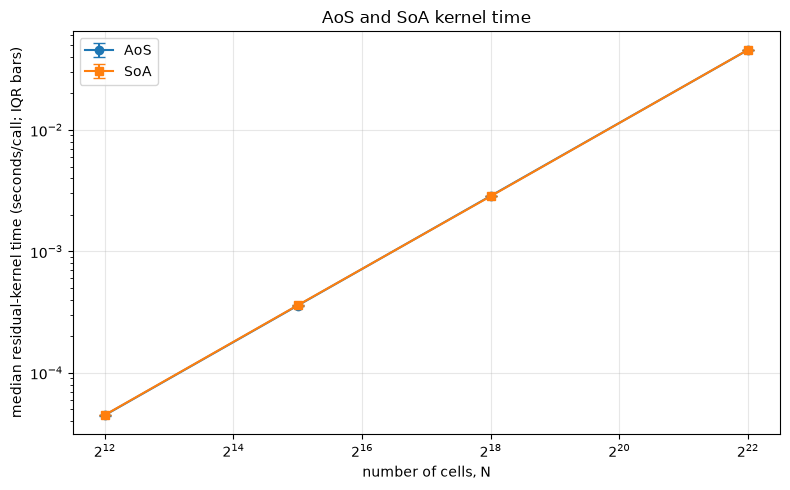

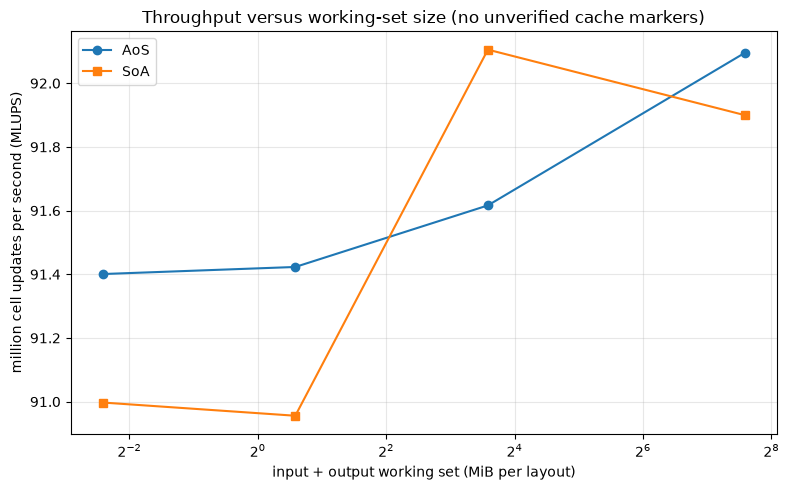

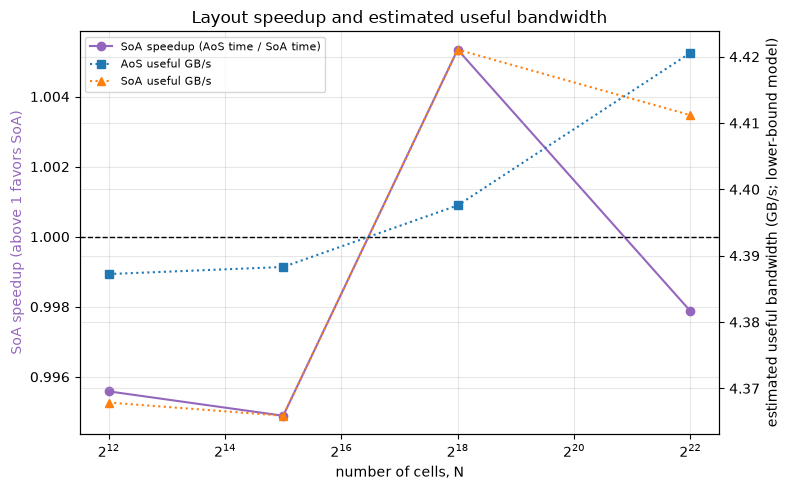

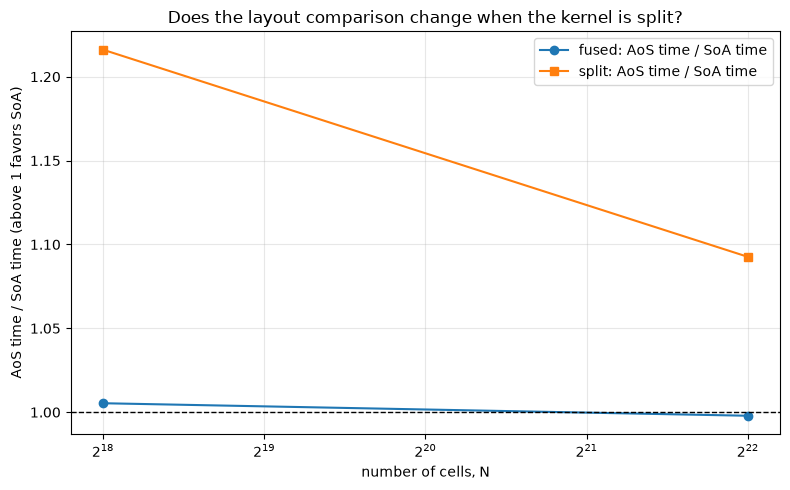

### Interpretation of this run

- SoA was faster at 1 of 4 sizes and AoS at 3; the AoS-time/SoA-time ratios ranged from 0.995 to 1.005. The largest SoA advantage occurred at N=262,144; its smallest ratio was at N=32,768.
- Successive throughput ratios (larger size divided by preceding size) were [('AoS', [1.0002431278229644, 1.0021148010309058, 1.0052266099634712]), ('SoA', [0.9995440755526598, 1.0126401447175601, 0.9977673564226107])]. Across this run, throughput ranged from 90.96 to 92.11 MLUPS, so there is no clear cache-exit knee in the measured points. Exact L2/L3 sizes were not reliably available, so do not assign a transition to a particular cache.
- AoS has cell stride 24 bytes and field stride 8 bytes; SoA has cell stride 8 bytes within each field. The former places the three values consumed together nearby; the latter creates regular field streams that can help vectorization. The speedup measurements show which effect won for this fused loop and compiler.
- The useful-bandwidth estimate divides 48 required bytes per cell by time. It is not a DRAM counter: adjacent fluxes reuse values, cache hits may satisfy reads, stores can trigger write allocation, and prefetching/compiler transformations change physical traffic. Without hardware counters and a reliable peak-bandwidth measurement it cannot establish a fraction of peak DRAM bandwidth.
- For this CPU kernel, prefer the layout that wins consistently across the sizes and matters to the full application; if results are mixed, benchmark the production loop and surrounding reconstruction/update stages before committing. For a GPU, add device measurements of coalesced access, occupancy, register pressure, achieved memory bandwidth, launch overhead, and end-to-end solver performance before deciding.
- In the two largest cases, the fused and split AoS/SoA time ratios were [(262144, 1.0053391411072472, 1.216131383726964), (4194304, 0.9978790525324507, 1.092629996964861)]; the measured winner changed between fused and split forms. The split version also pays to write and reread four temporary fields, so any reduction in repeated flux arithmetic must outweigh both that traffic and the extra pass overhead.

Arithmetic-intensity estimate: about 85 basic arithmetic ops / 48 useful bytes = 1.77 nominal ops/byte; divisions, square roots, and comparisons have different costs.


In [20]:
from IPython.display import display, Markdown

# Put the measured metadata and units beside the table, not only in hidden
# variables, so the performance data remain interpretable when shared.
print("Measured environment:", SOFTWARE_CONTEXT)
table_header = "| N | layout | median (s/call) | IQR (s) | MLUPS | estimated useful GB/s | working set (MiB) | batch |"
table_separator = "|---:|:---|---:|---:|---:|---:|---:|---:|"
table_rows = [table_header, table_separator]
for record in records:
    table_rows.append(
        f"| {record['N']:,} | {record['layout']} | {record['median_s']:.4e} "
        f"| {record['iqr_s']:.3e} | {record['mlups']:.2f} "
        f"| {record['estimated_useful_gbps']:.3f} "
        f"| {record['working_set_bytes'] / 2**20:.2f} | {record['batch_count']:,} |"
    )
display(Markdown("\n".join(table_rows)))

# Plot 1: median time and the interquartile range. Log axes expose both the
# roughly linear scaling with N and any changes in per-cell efficiency.
fig, ax = plt.subplots(figsize=(8, 5))
for layout, marker in (("AoS", "o"), ("SoA", "s")):
    subset = sorted((r for r in records if r["layout"] == layout), key=lambda r: r["N"])
    sizes = np.array([r["N"] for r in subset])
    medians = np.array([r["median_s"] for r in subset])
    lower = medians - np.array([r["q1_s"] for r in subset])
    upper = np.array([r["q3_s"] for r in subset]) - medians
    ax.errorbar(sizes, medians, yerr=np.vstack((lower, upper)),
                marker=marker, capsize=4, linewidth=1.5, label=layout)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("number of cells, N")
ax.set_ylabel("median residual-kernel time (seconds/call; IQR bars)")
ax.set_title("AoS and SoA kernel time")
ax.legend()
fig.tight_layout()
plt.show()

# Plot 2: throughput against the input-plus-output working set for one
# configuration. Cache markers are omitted because cache sizes were not
# reliably discoverable on this machine, rather than guessed.
fig, ax = plt.subplots(figsize=(8, 5))
for layout, marker in (("AoS", "o"), ("SoA", "s")):
    subset = sorted((r for r in records if r["layout"] == layout), key=lambda r: r["N"])
    working_mib = [r["working_set_bytes"] / 2**20 for r in subset]
    throughput = [r["mlups"] for r in subset]
    ax.plot(working_mib, throughput, marker=marker, linewidth=1.5, label=layout)
ax.set_xscale("log", base=2)
ax.set_xlabel("input + output working set (MiB per layout)")
ax.set_ylabel("million cell updates per second (MLUPS)")
ax.set_title("Throughput versus working-set size (no unverified cache markers)")
ax.legend()
fig.tight_layout()
plt.show()

# Plot 3: speedup is defined as AoS time / SoA time, so values above one
# favor SoA. The second axis shows the 48-byte lower-bound useful bandwidth,
# not physical DRAM traffic or measured hardware bandwidth.
speedup_points = []
for n in SIZES:
    aos = next(r for r in records if r["N"] == n and r["layout"] == "AoS")
    soa = next(r for r in records if r["N"] == n and r["layout"] == "SoA")
    speedup_points.append((n, aos["median_s"] / soa["median_s"]))
fig, ax = plt.subplots(figsize=(8, 5))
ax2 = ax.twinx()
ax.plot([x[0] for x in speedup_points], [x[1] for x in speedup_points],
        color="tab:purple", marker="o", label="SoA speedup (AoS time / SoA time)")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
for layout, color, marker in (("AoS", "tab:blue", "s"), ("SoA", "tab:orange", "^") ):
    subset = sorted((r for r in records if r["layout"] == layout), key=lambda r: r["N"])
    ax2.plot([r["N"] for r in subset], [r["estimated_useful_gbps"] for r in subset],
             color=color, marker=marker, linestyle=":", label=f"{layout} useful GB/s")
ax.set_xscale("log", base=2)
ax.set_xlabel("number of cells, N")
ax.set_ylabel("SoA speedup (above 1 favors SoA)", color="tab:purple")
ax2.set_ylabel("estimated useful bandwidth (GB/s; lower-bound model)")
ax.set_title("Layout speedup and estimated useful bandwidth")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)
fig.tight_layout()
plt.show()

# Optional stretch plot: compare AoS time / SoA time before and after
# splitting the kernel. Values above one favor SoA; below one favor AoS.
fig, ax = plt.subplots(figsize=(8, 5))
for kernel_form, source in (("fused", records), ("split", split_records)):
    ratios = []
    for n in SIZES[-2:]:
        aos = next(r for r in source if r["N"] == n and r["layout"] == "AoS")
        soa = next(r for r in source if r["N"] == n and r["layout"] == "SoA")
        ratios.append(aos["median_s"] / soa["median_s"])
    ax.plot(SIZES[-2:], ratios, marker="o" if kernel_form == "fused" else "s",
            linewidth=1.5, label=f"{kernel_form}: AoS time / SoA time")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_xscale("log", base=2)
ax.set_xlabel("number of cells, N")
ax.set_ylabel("AoS time / SoA time (above 1 favors SoA)")
ax.set_title("Does the layout comparison change when the kernel is split?")
ax.legend()
fig.tight_layout()
plt.show()

# Summarize the complete size range; do not declare a winner from only the
# largest case. These observed ratios are specific to this CPU/compiler run.
speedups = np.array([ratio for _, ratio in speedup_points])
wins_soa = int(np.sum(speedups > 1.0))
wins_aos = int(np.sum(speedups < 1.0))
best_soa_size = speedup_points[int(np.argmax(speedups))][0]
worst_soa_size = speedup_points[int(np.argmin(speedups))][0]
throughput_transitions = []
for layout in ("AoS", "SoA"):
    subset = sorted((r for r in records if r["layout"] == layout), key=lambda r: r["N"])
    changes = [subset[i + 1]["mlups"] / subset[i]["mlups"]
               for i in range(len(subset) - 1)]
    throughput_transitions.append((layout, changes))
split_layout_ratios = []
for n in SIZES[-2:]:
    fused_aos = next(r for r in records if r["N"] == n and r["layout"] == "AoS")
    fused_soa = next(r for r in records if r["N"] == n and r["layout"] == "SoA")
    split_aos = next(r for r in split_records if r["N"] == n and r["layout"] == "AoS")
    split_soa = next(r for r in split_records if r["N"] == n and r["layout"] == "SoA")
    split_layout_ratios.append((n, fused_aos["median_s"] / fused_soa["median_s"],
                               split_aos["median_s"] / split_soa["median_s"]))
layout_winner_changed = any((fused_ratio - 1.0) * (split_ratio - 1.0) < 0.0
                             for _, fused_ratio, split_ratio in split_layout_ratios)
display(Markdown(
    "### Interpretation of this run\n\n"
    f"- SoA was faster at {wins_soa} of {len(speedups)} sizes and AoS at {wins_aos}; "
    f"the AoS-time/SoA-time ratios ranged from {speedups.min():.3f} to {speedups.max():.3f}. "
    f"The largest SoA advantage occurred at N={best_soa_size:,}; its smallest ratio was at N={worst_soa_size:,}.\n"
    f"- Successive throughput ratios (larger size divided by preceding size) were "
    f"{throughput_transitions}. Across this run, throughput ranged from "
    f"{min(r['mlups'] for r in records):.2f} to {max(r['mlups'] for r in records):.2f} MLUPS, "
    "so there is no clear cache-exit knee in the measured points. Exact L2/L3 sizes "
    "were not reliably available, so do not assign a transition to a particular cache.\n"
    "- AoS has cell stride 24 bytes and field stride 8 bytes; SoA has cell stride 8 bytes "
    "within each field. The former places the three values consumed together nearby; "
    "the latter creates regular field streams that can help vectorization. The speedup "
    "measurements show which effect won for this fused loop and compiler.\n"
    "- The useful-bandwidth estimate divides 48 required bytes per cell by time. It is "
    "not a DRAM counter: adjacent fluxes reuse values, cache hits may satisfy reads, "
    "stores can trigger write allocation, and prefetching/compiler transformations "
    "change physical traffic. Without hardware counters and a reliable peak-bandwidth "
    "measurement it cannot establish a fraction of peak DRAM bandwidth.\n"
    "- For this CPU kernel, prefer the layout that wins consistently across the sizes "
    "and matters to the full application; if results are mixed, benchmark the production "
    "loop and surrounding reconstruction/update stages before committing. For a GPU, "
    "add device measurements of coalesced access, occupancy, register pressure, achieved "
    "memory bandwidth, launch overhead, and end-to-end solver performance before deciding.\n"
    f"- In the two largest cases, the fused and split AoS/SoA time ratios were {split_layout_ratios}; "
    f"the measured winner {'changed' if layout_winner_changed else 'did not change'} between fused and split forms. "
    "The split version also pays to write and reread four temporary fields, so any reduction in "
    "repeated flux arithmetic must outweigh both that traffic and the extra pass overhead."
))

# This fused implementation evaluates two face fluxes per cell. A transparent
# nominal count is about 85 basic +,-,*,/ operations per cell: roughly 13 for
# each of four primitive/physical-flux evaluations, 15 per face, and 3 final
# residual subtractions. That gives 85/48 ~= 1.77 nominal FLOP/byte. This is
# only a rough model: division and sqrt differ in cost from add/multiply, and
# abs/max comparisons are not FLOPs. It must not be confused with measured intensity.
print("Arithmetic-intensity estimate: about 85 basic arithmetic ops / 48 useful bytes "
      "= 1.77 nominal ops/byte; divisions, square roots, and comparisons have different costs.")


## 6. Automatic success checks

Assert all of the following:

- Input states have positive density and pressure and all arrays are float64, 1D/2D as specified, and C-contiguous.
- AoS and SoA residuals meet the relative and absolute equivalence tolerances.
- Each conserved residual sums to roundoff-scaled zero under the periodic boundary.
- No input changes across a kernel call; output is overwritten on repeat.
- Every timed sample is positive and finite; every configuration has nine samples; compilation signatures exist before timing.
- Reported rates recompute from N and median time; estimated bandwidth uses exactly the documented 48-byte lower bound.
- At least one case is larger than 100 MiB for combined input and output, so the experiment is not entirely cache-resident on typical workstations.

Do **not** assert that SoA must be faster. Layout performance is hardware-, compiler-, and kernel-dependent; a forced expected winner would invalidate the experiment.

In [21]:
# Assert state admissibility and storage layout for the checked instance.
rho_values = U_check[:, 0]
velocity_values = U_check[:, 1] / rho_values
pressure_values = (GAMMA - 1.0) * (U_check[:, 2] - 0.5 * U_check[:, 1] * velocity_values)
assert np.all(rho_values > 0.0) and np.all(pressure_values > 0.0)
assert U_check.dtype == np.float64 and U_check.ndim == 2 and U_check.flags.c_contiguous
assert all(a.dtype == np.float64 and a.ndim == 1 and a.flags.c_contiguous
           for a in (rho_check, mom_check, energy_check))

# Correctness-cell comparisons already assert equivalence, conservation,
# overwrite behavior, and input immutability. Confirm kernels were compiled.
assert residual_aos.signatures and residual_soa.signatures

# Every record must carry nine finite positive samples and metrics derived
# from its median time and documented 48-byte useful-traffic assumption.
assert len(records) == len(SIZES) * 2
for record in records:
    samples = record["samples_s"]
    assert len(samples) == REPEATS
    assert np.isfinite(samples).all() and np.all(samples > 0.0)
    assert record["signatures_present"]
    assert np.isclose(record["mlups"], record["N"] / record["median_s"] / 1e6)
    assert record["useful_bytes"] == 48 * record["N"]
    assert np.isclose(record["estimated_useful_gbps"],
                      48 * record["N"] / record["median_s"] / 1e9)
    assert record["working_set_bytes"] == 6 * 8 * record["N"]

# Verify the largest input/output footprint exceeds 100 MiB as required.
largest_working_set = max(record["working_set_bytes"] for record in records)
assert largest_working_set > 100 * 2**20
assert all(record["repeats"] == 9 for record in records)

# The optional two-pass kernels must preserve the fused numerical result and
# report their larger scratch footprint/traffic without enforcing a winner.
assert len(split_records) == 2 * len(SIZES[-2:])
for record in split_records:
    assert len(record["samples_s"]) == REPEATS
    assert np.isfinite(record["samples_s"]).all() and np.all(record["samples_s"] > 0.0)
    assert record["signatures_present"]
    assert record["max_fused_difference"] <= 5e-13
    assert record["working_set_bytes"] == 80 * record["N"]
    assert record["traffic_bytes"] == 136 * record["N"]
    assert np.isclose(record["estimated_useful_gbps"],
                      record["traffic_bytes"] / record["median_s"] / 1e9)

print("All input, output, compiled-signature, fused/split correctness, timing-protocol, and traffic-model checks passed.")
print(f"Largest single-layout fused working set: {largest_working_set / 2**20:.1f} MiB")
# No assertion chooses a faster layout: a slower result remains a valid measurement.


All input, output, compiled-signature, fused/split correctness, timing-protocol, and traffic-model checks passed.
Largest single-layout fused working set: 192.0 MiB


## 7. Discussion, stretch goal, and references

**Stretch goal:** Split each layout into two passes: (1) primitive variables and spectral radii, then (2) face flux/residual. Rebenchmark at the two largest sizes. Account for every new temporary in the working set and useful-traffic model. Determine whether the layout conclusion changes when field-wise arrays are reused across kernels. Do not enable parallel execution until the single-thread comparison is complete.

### Scope and limitations

This microbenchmark isolates one periodic CPU kernel. It does not include reconstruction, limiters, viscous terms, MPI halos, memory allocation, or GPU execution. Numba/LLVM choices may differ from C++/Kokkos. Useful-bandwidth estimates are analytical lower bounds, not performance-counter measurements. Frequency scaling and background load can affect results; retain raw timing samples.

### References

- **Dedicated project reference:** Samuel Williams, Andrew Waterman, and David Patterson, "Roofline: An Insightful Visual Performance Model for Multicore Architectures," *Communications of the ACM* 52(4), 65-76, 2009. [Open record and PDF](https://escholarship.org/uc/item/78h8v7mr). Use it to distinguish arithmetic intensity, attainable ceilings, and measured performance.
- **Layout reference:** [Kokkos View programming guide](https://kokkos.org/kokkos-core-wiki/ProgrammingGuide/View.html) for layout-aware multidimensional arrays and memory spaces.
- **Implementation reference:** [Numba performance tips](https://numba.readthedocs.io/en/stable/user/performance-tips.html) for nopython compilation and benchmarking-relevant behavior.
- **Research paper:** Benjamin Wilfong et al., "Simulating many-engine spacecraft: Exceeding 1 quadrillion degrees of freedom via information geometric regularization," *Proceedings of SC '25*, pp. 14-24, 2025. DOI: 10.1145/3712285.3771783. [Author PDF](https://benwilfong.com/papers/wilfong-GB.pdf). Read for the interaction among memory footprint, precision, unified memory, and energy-to-solution at extreme-scale CFD.